# 3. Model Training & Comparison

Train and compare multiple regression models: Linear Regression, Polynomial Regression, KNN, and XGBoost.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

%matplotlib inline

## Load Prepared Data

In [ ]:
with open("../dataset/processed/train_val_test_split.pkl", 'rb') as f:
    data_dict = pickle.load(f)

X_train, y_train = data_dict['X_train'], data_dict['y_train']
X_val, y_val = data_dict['X_val'], data_dict['y_val']
X_test, y_test = data_dict['X_test'], data_dict['y_test']

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

## Model 1: Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Training evaluation
y_pred_train = lr_model.predict(X_train)
lr_train_mae = mean_absolute_error(y_train, y_pred_train)
lr_train_r2 = r2_score(y_train, y_pred_train)

# Validation evaluation
y_pred_val = lr_model.predict(X_val)
lr_val_mae = mean_absolute_error(y_val, y_pred_val)
lr_val_r2 = r2_score(y_val, y_pred_val)

print("LINEAR REGRESSION")
print(f"  Training   - MAE: {lr_train_mae:.2f}, R²: {lr_train_r2:.4f}")
print(f"  Validation - MAE: {lr_val_mae:.2f}, R²: {lr_val_r2:.4f}")

## Model 2: Polynomial Regression (Degree 2)

In [ ]:
poly2_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
poly2_model.fit(X_train, y_train)

# Training evaluation
y_pred_train = poly2_model.predict(X_train)
poly2_train_mae = mean_absolute_error(y_train, y_pred_train)
poly2_train_r2 = r2_score(y_train, y_pred_train)

# Validation evaluation
y_pred_val = poly2_model.predict(X_val)
poly2_val_mae = mean_absolute_error(y_val, y_pred_val)
poly2_val_r2 = r2_score(y_val, y_pred_val)

print("POLYNOMIAL REGRESSION (Degree 2)")
print(f"  Training   - MAE: {poly2_train_mae:.2f}, R²: {poly2_train_r2:.4f}")
print(f"  Validation - MAE: {poly2_val_mae:.2f}, R²: {poly2_val_r2:.4f}")

## Model 3: Polynomial Regression (Degree 3)

In [ ]:
poly3_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
poly3_model.fit(X_train, y_train)

# Training evaluation
y_pred_train = poly3_model.predict(X_train)
poly3_train_mae = mean_absolute_error(y_train, y_pred_train)
poly3_train_r2 = r2_score(y_train, y_pred_train)

# Validation evaluation
y_pred_val = poly3_model.predict(X_val)
poly3_val_mae = mean_absolute_error(y_val, y_pred_val)
poly3_val_r2 = r2_score(y_val, y_pred_val)

print("POLYNOMIAL REGRESSION (Degree 3)")
print(f"  Training   - MAE: {poly3_train_mae:.2f}, R²: {poly3_train_r2:.4f}")
print(f"  Validation - MAE: {poly3_val_mae:.2f}, R²: {poly3_val_r2:.4f}")

## Model 4: K-Nearest Neighbors

In [ ]:
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=3, weights='distance'))
])
knn_model.fit(X_train, y_train)

# Training evaluation
y_pred_train = knn_model.predict(X_train)
knn_train_mae = mean_absolute_error(y_train, y_pred_train)
knn_train_r2 = r2_score(y_train, y_pred_train)

# Validation evaluation
y_pred_val = knn_model.predict(X_val)
knn_val_mae = mean_absolute_error(y_val, y_pred_val)
knn_val_r2 = r2_score(y_val, y_pred_val)

print("K-NEAREST NEIGHBORS (k=3)")
print(f"  Training   - MAE: {knn_train_mae:.2f}, R²: {knn_train_r2:.4f}")
print(f"  Validation - MAE: {knn_val_mae:.2f}, R²: {knn_val_r2:.4f}")

## Model 5: XGBoost with Hyperparameter Tuning

In [ ]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    verbosity=0
)

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

print("Performing RandomizedSearchCV for XGBoost...")
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)

print(f"\nBest R² Score: {search.best_score_:.4f}")
print(f"Best Parameters: {search.best_params_}")

## XGBoost Best Model Evaluation

In [29]:
best_xgb = search.best_estimator_

# Training evaluation
y_pred_train = best_xgb.predict(X_train)
xgb_train_mae = mean_absolute_error(y_train, y_pred_train)
xgb_train_r2 = r2_score(y_train, y_pred_train)

# Validation evaluation
y_pred_val = best_xgb.predict(X_val)
xgb_val_mae = mean_absolute_error(y_val, y_pred_val)
xgb_val_r2 = r2_score(y_val, y_pred_val)

print("XGBOOST (Best)")
print(f"  Training   - MAE: {xgb_train_mae:.2f}, R²: {xgb_train_r2:.4f}")
print(f"  Validation - MAE: {xgb_val_mae:.2f}, R²: {xgb_val_r2:.4f}")

XGBOOST (Best)
  Training   - MAE: 667.46, R²: 0.9069
  Validation - MAE: 728.64, R²: 0.8863


## Model Comparison

In [30]:
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial (Deg 2)', 'Polynomial (Deg 3)', 'KNN (k=3)', 'XGBoost (Best)'],
    'Train MAE': [lr_train_mae, poly2_train_mae, poly3_train_mae, knn_train_mae, xgb_train_mae],
    'Val MAE': [lr_val_mae, poly2_val_mae, poly3_val_mae, knn_val_mae, xgb_val_mae],
    'Train R²': [lr_train_r2, poly2_train_r2, poly3_train_r2, knn_train_r2, xgb_train_r2],
    'Val R²': [lr_val_r2, poly2_val_r2, poly3_val_r2, knn_val_r2, xgb_val_r2]
})

print("\nModel Comparison Summary:")
print(models_comparison.to_string(index=False))


Model Comparison Summary:
             Model   Train MAE     Val MAE  Train R²   Val R²
 Linear Regression 1154.583097 1156.529472  0.729834 0.729074
Polynomial (Deg 2) 1105.434235 1104.106223  0.758451 0.758890
Polynomial (Deg 3) 1093.030011 1091.467552  0.765971 0.766409
         KNN (k=3)   21.283283  893.128560  0.999228 0.807262
    XGBoost (Best)  667.455994  728.637756  0.906875 0.886297


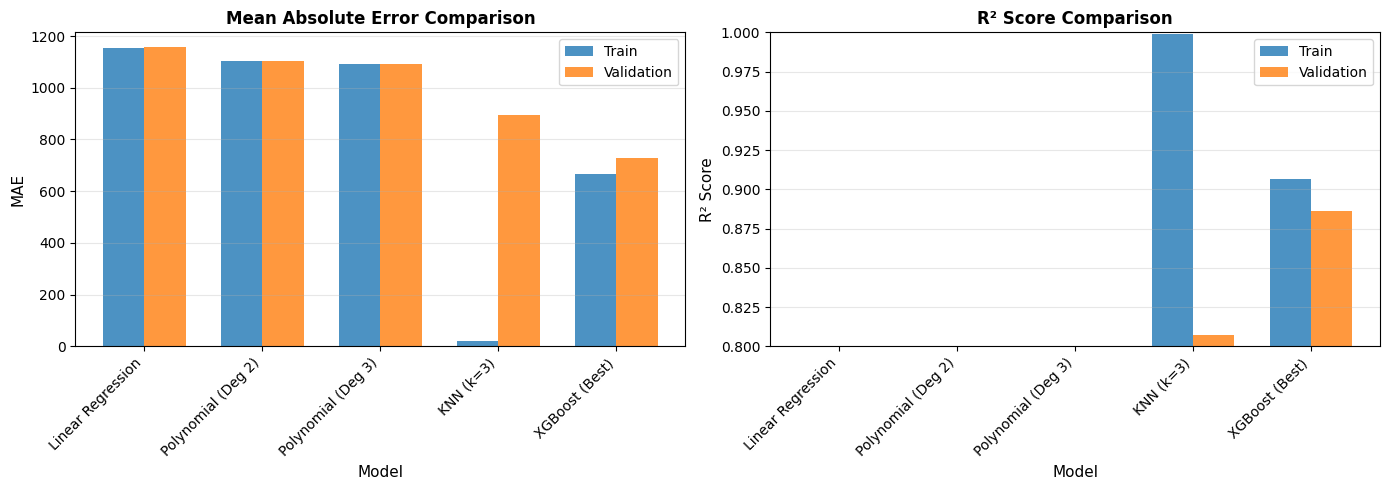

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE Comparison
x_pos = np.arange(len(models_comparison))
width = 0.35

axes[0].bar(x_pos - width/2, models_comparison['Train MAE'], width, label='Train', alpha=0.8)
axes[0].bar(x_pos + width/2, models_comparison['Val MAE'], width, label='Validation', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].set_title('Mean Absolute Error Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_comparison['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# R² Comparison
axes[1].bar(x_pos - width/2, models_comparison['Train R²'], width, label='Train', alpha=0.8)
axes[1].bar(x_pos + width/2, models_comparison['Val R²'], width, label='Validation', alpha=0.8)
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_comparison['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0.8, 1.0])

plt.tight_layout()
plt.show()

## Save Best Model

In [34]:
import os

models_folder = "../models"
os.makedirs(models_folder, exist_ok=True)

with open(f"{models_folder}/linear_regression_model.pkl", 'wb') as f:
    pickle.dump(lr_model, f)

with open(f"{models_folder}/polynomial_degree2_model.pkl", 'wb') as f:
    pickle.dump(poly2_model, f)

with open(f"{models_folder}/polynomial_degree3_model.pkl", 'wb') as f:
    pickle.dump(poly3_model, f)

with open(f"{models_folder}/knn_model.pkl", 'wb') as f:
    pickle.dump(knn_model, f)

with open(f"{models_folder}/best_xgboost_model.pkl", 'wb') as f:
    pickle.dump(best_xgb, f)

print(f"Linear Regression model saved to {models_folder}/linear_regression_model.pkl")
print(f"Polynomial (Degree 2) model saved to {models_folder}/polynomial_degree2_model.pkl")
print(f"Polynomial (Degree 3) model saved to {models_folder}/polynomial_degree3_model.pkl")
print(f"KNN model saved to {models_folder}/knn_model.pkl")
print(f"Best XGBoost model saved to {models_folder}/best_xgboost_model.pkl")

Linear Regression model saved to ../models/linear_regression_model.pkl
Polynomial (Degree 2) model saved to ../models/polynomial_degree2_model.pkl
Polynomial (Degree 3) model saved to ../models/polynomial_degree3_model.pkl
KNN model saved to ../models/knn_model.pkl
Best XGBoost model saved to ../models/best_xgboost_model.pkl


## Generate Predictions on Inference Data

In [36]:
def preprocess_data(df, drop_col, target_col):
    """ Drops one column and converts values in target_col: '0', 'A', 'B', 'C' -> 1.0 """
    df = df.copy()

    # Drop the column
    df = df.drop(columns=[drop_col])

    # # Replace values with 1.0
    df[target_col] = df[target_col].replace({ '0': 0.0, 'a': 1.0, 'b': 1.0, 'c': 1.0 }).astype(int)

    return df

In [44]:
inference_df = pd.read_csv("../dataset/inference.csv")

df_copy = inference_df.copy()

# Drop unnecessary columns
df_copy = preprocess_data(df_copy, "date", "state_holiday")
df_copy = preprocess_data(df_copy, "index", "state_holiday")

# Considering the sales only when the shop is open
df_copy = df_copy[df_copy["open"]==1]
df_copy = preprocess_data(df_copy, "open", "state_holiday")

display(df_copy.head())

# Generate predictions using best model
y = best_xgb.predict(df_copy)

# Create results dataframe
inference_df['sales'] = 0  # default for closed rows

open_mask = inference_df['open'] == 1

# Fail loudly on a mismatch instead of a cryptic crash or a silent wrong-row assignment
assert open_mask.sum() == len(y), (
    f"Mismatch: {open_mask.sum()} open rows but {len(y)} predictions"
)

inference_df.loc[open_mask, 'sales'] = np.round(y)

# Save predictions
results_folder = "../results"
os.makedirs(results_folder, exist_ok=True)
inference_df.to_csv(f"../group3.csv", index=False)

print(f"Generated predictions for {len(y)} inference samples")
print(f"Results saved to {results_folder}/inference_predictions.csv")
print(f"\nPrediction statistics:")
print(f"  Mean predicted sales: {y.mean():.2f}")
print(f"  Std dev: {y.std():.2f}")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")

,store_ID,day_of_week,nb_customers_on_day,promotion,state_holiday,school_holiday
2,404,3,657,1,0,0
3,683,2,862,0,0,0
4,920,3,591,1,0,0
5,758,4,569,0,0,0
6,563,1,321,1,0,0


Generated predictions for 59105 inference samples
Results saved to ../results/inference_predictions.csv

Prediction statistics:
  Mean predicted sales: 6946.99
  Std dev: 2919.81
  Min: 600.04
  Max: 32762.92
